In [235]:
rm(list = ls())

options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 300)
options(bitmapType = "quartz")

In [236]:
library(tidyverse)
library(readxl)
library(janitor)
library(lubridate)
library(zoo)
library(scales)
library(paletteer)
library(showtext)
library(arrow)
library(patchwork)
library(gridExtra)

In [237]:
#font_path <- "/Users/Ben.Pharris/Library/Fonts/Roboto-VariableFont_wdth,wght.ttf"
#
#font_add_google("Roboto", "roboto")
#showtext_auto()

In [238]:
ga_2025 <- read_excel('/Users/Ben.Pharris/Downloads/Data Tables 2025.xlsx')
ga_2024 <- read_excel('/Users/Ben.Pharris/Downloads/Data Tables 2024.xlsx')

New names:
• `` -> `...9`
New names:
• `` -> `...9`


In [239]:
s1 <- read_parquet('/Users/Ben.Pharris/Documents/project-dev/Media Measurement/data/clean/national_cleaned.parquet')
s2 <- read_parquet('/Users/Ben.Pharris/Documents/project-dev/Media Measurement/data/clean/new_national_cleaned.parquet')

In [240]:
old_spending <- s1 %>% 
  select(-Platform) %>% 
  mutate(Date = as.Date(Date)) %>%
  filter(Sales_Channel == 'Indirect' | Sales_Channel == 'Web') %>%
  group_by(Date, Funnel, Sales_Channel) %>%
  summarise(Spend = sum(Spend))

  old_spending$Funnel <- recode(old_spending$Funnel,
    `Lower Funnel` = 'Lower',
    `Upper Funnel` = 'Upper'
  )

`summarise()` has grouped output by 'Date', 'Funnel'. You can override using the `.groups` argument.


In [241]:
  s2$Funnel <- recode(s2$Funnel,
    `Middle` = 'Upper',
  )

new_spending <- s2 %>% 
  select(-Platform) %>%
  mutate(Date = as.Date(Date)) %>%
  filter(Sales_Channel == 'Indirect' | Sales_Channel == 'Web') %>%
  group_by(Date, Funnel, Sales_Channel) %>%
  summarise(Spend = sum(Spend))

`summarise()` has grouped output by 'Date', 'Funnel'. You can override using the `.groups` argument.


In [242]:
old_spending <- old_spending %>%
  filter(Date < min(new_spending$Date))

In [243]:
spending <- rbind(old_spending, new_spending)

In [244]:
ga_2024 <- ga_2024 %>%
  select(-contains('VAR')) %>%
  mutate(across(-c(Date), ~parse_number(as.character(.))))%>%
  mutate(Date = mdy(Date))

ga_2025 <- ga_2025 %>%
  select(-contains('VAR')) %>%
  mutate(across(-c(Date), ~parse_number(as.character(.))))%>%
  mutate(Date = mdy(Date))

In [245]:
combined_GA <- rbind(ga_2024, ga_2025)

In [246]:
#fullGA <- read_excel('/Users/Ben.Pharris/Downloads/Big_GA.xlsx')%>%
#  mutate(across(-c(Date), ~parse_number(as.character(.))))%>%
#  mutate(Date = mdy(Date))

In [247]:
combined_GA <- combined_GA %>%
  mutate(Quarter = as.yearqtr(Date))

combined_GA$Quarter_Factor <- as.factor(combined_GA$Quarter)

In [248]:
combined_GA <- combined_GA %>%
  mutate(Month = as.yearmon(Date))

combined_GA$Month_Factor <- as.factor(combined_GA$Month)

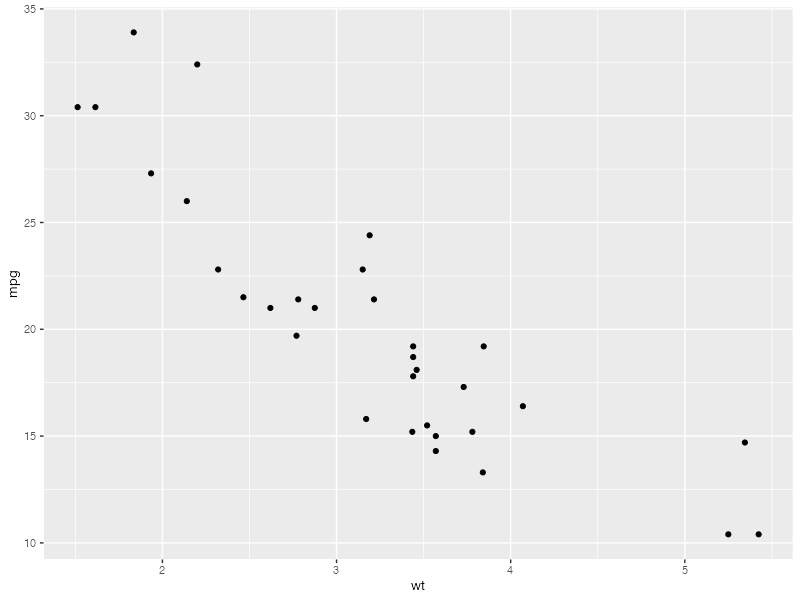

In [249]:
library(ggplot2)
# Reset theme to default to rule out dark_vibes
theme_set(theme_grey()) 

ggplot(mtcars, aes(wt, mpg)) + geom_point()

Warning messages:
1: Removed 24 rows containing non-finite outside the scale range (`stat_smooth()`). 
2: Removed 24 rows containing missing values or values outside the scale range (`geom_col()`). 


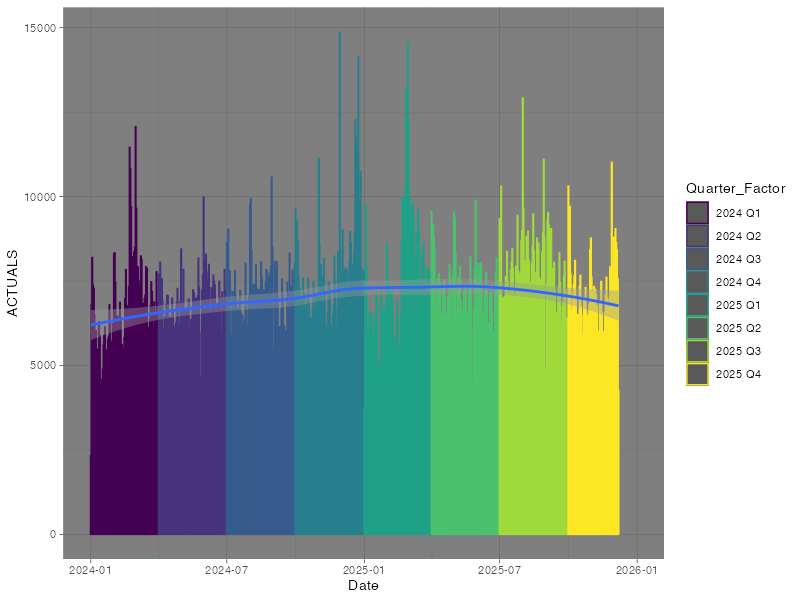

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [250]:
ggplot(combined_GA) + geom_col( aes(x= Date, y = ACTUALS, color = Quarter_Factor)) + scale_color_viridis_d() + geom_smooth(aes(x= Date, y = ACTUALS)) + theme_dark()

In [251]:
weekly_labeled <- combined_GA %>%
  mutate(
    week_start = floor_date(Date, "week", week_start = 1),
    week_end   = week_start + days(6)
  ) %>%
  group_by(week_start, week_end) %>%
  summarise(across(where(is.numeric), sum, na.rm = TRUE)) %>%
  
  # Create the label
  mutate(
    week_label = paste(format(week_start, "%b %d"), "-", format(week_end, "%b %d"))
  )

weekly_labeled <- weekly_labeled %>%
  mutate(Quarter = as.yearqtr(week_start))

weekly_labeled$Quarter_Factor <- as.factor(weekly_labeled$Quarter)


`summarise()` has grouped output by 'week_start'. You can override using the `.groups` argument.


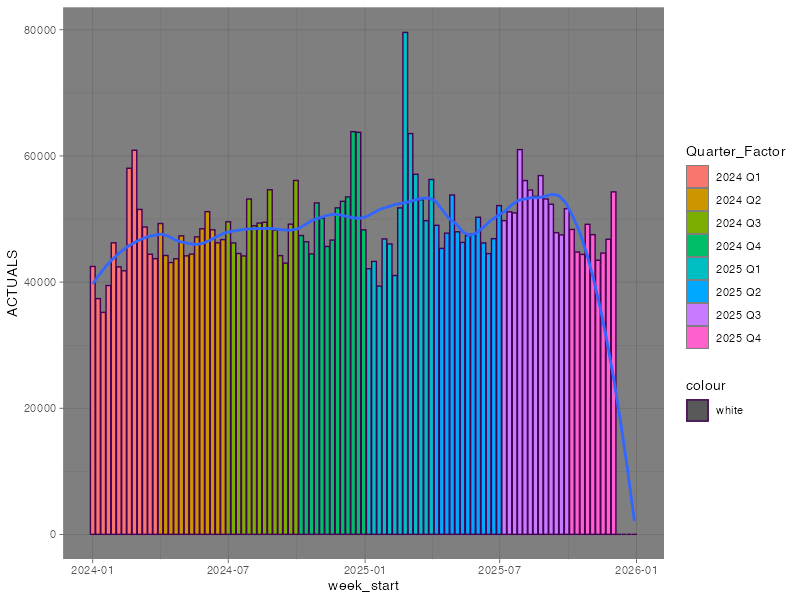

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [252]:
ggplot(weekly_labeled) + 
  geom_col( aes(x= week_start, y = ACTUALS, fill = Quarter_Factor, color = "white")) + 
  scale_color_viridis_d() + 
  geom_smooth(aes(x= week_start, y = ACTUALS), span = 0.33, se = FALSE) +
  theme_dark()

Warning messages:
1: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
2: Removed 12 rows containing missing values or values outside the scale range (`geom_point()`). 
3: Removed 12 rows containing missing values or values outside the scale range (`geom_line()`). 


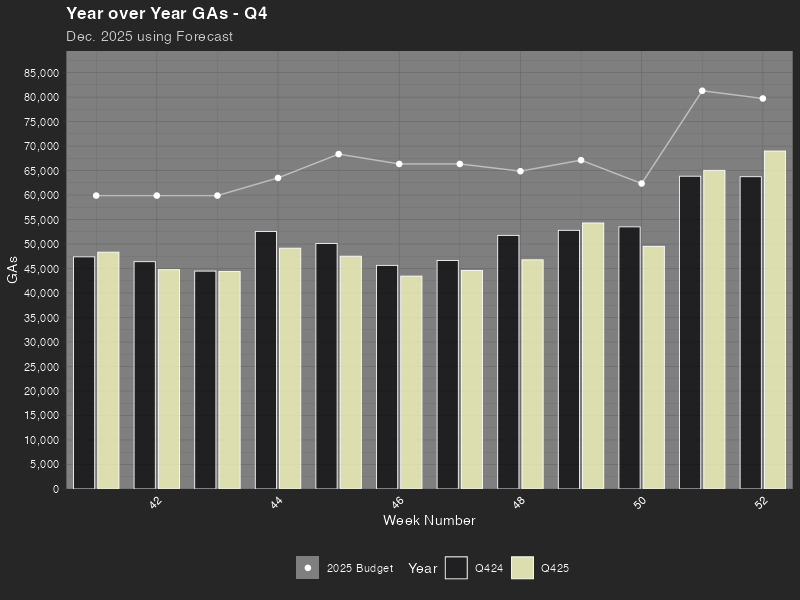

Warning messages:
1: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
3: Removed 12 rows containing missing values or values outside the scale range (`geom_point()`). 
4: Removed 12 rows containing missing values or values outside the scale range (`geom_line()`). 


In [253]:
yoy_q <- subset(weekly_labeled, Quarter %in% c('2024 Q4','2025 Q4') & week_start != '2024-12-30' & week_start != '2025-12-29')

# TRICK: Create a common x-axis index (Week Number)
# Depending on your data structure, you might use isoweek() or just rank the weeks.
yoy_q$Week_Index <- isoweek(yoy_q$week_start)

yoy_q <- yoy_q %>% 
  mutate(BUDGETS = na_if(BUDGETS, 0))

yoy_q <- yoy_q %>%
  mutate(FC_Impute_Flag = (ifelse(ACTUALS == 0, 1, 0))) %>%
  mutate(ACTUALS = (ifelse(ACTUALS == 0, FORECASTS, ACTUALS)))

ggplot(yoy_q, aes(x = Week_Index, group = Quarter_Factor)) + 
  
    # TRENDLINE: Darker shade (solid color)
#  geom_smooth(aes(y = ACTUALS, color = Quarter_Factor), 
#              se = FALSE, 
#              span = 0.75,
#              linewidth = 0.75, linetype = "longdash") +
  
  # BARS: Side-by-side with dodge
  geom_col(aes(y = ACTUALS, fill = Quarter_Factor), color = "white", linewidth = 0.3, 
           position = position_dodge(width = 0.8), 
           width = 0.7, alpha = 0.75) + 
  
  # POINTS (Budget)
  geom_point(aes(y = BUDGETS, shape = "2025 Budget"), 
             color = "white",
             size = 2) +
  
  geom_line(linewidth=0.5, alpha=0.5, aes(y = BUDGETS), color = "white")+
  
  # SCALES
  scale_fill_viridis_d(option="A", name = "Year", labels = c("Q424", "Q425"))+
  scale_color_viridis_d(option="A", name = "Trend", labels = c("Q424", "Q425")) +
  scale_shape_manual(name = "", values = c("2025 Budget" = 16)) +
  
  # AXIS FORMATTING
  scale_y_continuous(labels = scales::comma, 
                     n.breaks = 15, 
                     name = "GAs",
                     expand = expansion(mult = c(0, 0.1))) +
  
  scale_x_continuous(breaks = pretty_breaks(), name = "Week Number", expand = expansion(mult = c(0.01, 0.01))) +
  labs(title="Year over Year GAs - Q4", subtitle = "Dec. 2025 using Forecast")+
  theme_dark(base_family = "sans")+
  theme(
    # 1. Background Colors (The "Frame" Effect)
    panel.background = element_rect(fill = "grey50", color = NA), # The inner plot area (Standard theme_dark)
    plot.background  = element_rect(fill = "#262626", color = NA), # The outer frame (Darker!)
    legend.background = element_rect(fill = "#262626", color = NA), # Matches the frame
    legend.key = element_rect(fill = "grey50", color = NA),         # Matches the panel

    # 2. Text Colors (Everything White)
    text = element_text(color = "white"),                   # Global text default
    axis.text = element_text(color = "white"),              # Axes ticks
    axis.title = element_text(color = "white"),             # Axes labels
    plot.title = element_text(color = "white", face="bold"),# Title
    plot.subtitle = element_text(color = "#cccccc"),        # Subtitle (Slightly dimmer white)
    legend.text = element_text(color = "white"),            # Legend items
    legend.title = element_text(color = "white"),           # Legend title
    
    # 3. Positioning
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.margin = margin(t = 10, b = 10),
    
    # 4. Remove outer border if desired
    panel.border = element_blank(),
    main_family = "roboto"
  )

ggsave("YoYQ4.png", path = "./plts/", width = 12, height = 7.5, dpi = 300)

Warning messages:
1: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
2: Removed 30 rows containing missing values or values outside the scale range (`geom_point()`). 
3: Removed 30 rows containing missing values or values outside the scale range (`geom_line()`). 


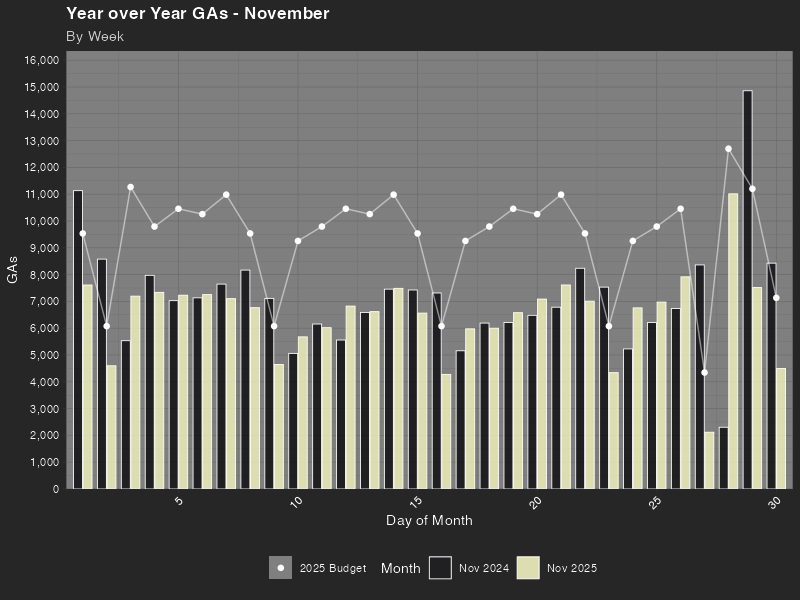

Warning messages:
1: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
3: Removed 30 rows containing missing values or values outside the scale range (`geom_point()`). 
4: Removed 30 rows containing missing values or values outside the scale range (`geom_line()`). 


In [254]:
yoy_m <- subset(combined_GA, Month %in% c('Nov 2024','Nov 2025'))

# TRICK: Create a common x-axis index (Day of Month)
yoy_m$Day_Index <- mday(yoy_m$Date) 

ggplot(yoy_m, aes(x = Day_Index, group = Quarter_Factor)) + 
  
  # TRENDLINE: Uses 'color'. Because bars have alpha 0.6 and this doesn't, 
  # this will appear as a "darker shade" of the same color.
#  geom_smooth(aes(y = ACTUALS, color = Quarter_Factor), 
#              se = FALSE, 
#              span = 0.75,
#              linewidth = 0.75, 
#              linetype = "longdash") + 
  
  
  # BARS: Use 'fill' instead of color. Alpha makes them lighter than the line.
  # position_dodge puts them side by side.
  geom_col(aes(y = ACTUALS, fill = Quarter_Factor), color = "white", linewidth = 0.3, 
           position = position_dodge(width = 0.8), 
           width = 0.75, 
           alpha = 0.75) + 
  
  # POINTS (Budget): Map shape to a string to force a Legend entry. 
  # We hardcode color to white (or another contrast color) to stand out against theme_dark
  geom_point(aes(y = BUDGETS, shape = "2025 Budget"), 
             color = "white", 
             size = 2) +
   geom_line(linewidth=0.5, alpha=0.5, aes(y = BUDGETS), color = "white")+
  
  # SCALES
  scale_fill_viridis_d(name = "Month", labels = c("Nov 2024", "Nov 2025"), option = "A") +
  scale_color_viridis_d(name = "Trend", labels = c("Nov 2024", "Nov 2025"), option = "A") +
  scale_shape_manual(name = "", values = c("2025 Budget" = 16)) + # 16 is a solid circle
  
  # AXIS FORMATTING
  scale_y_continuous(labels = scales::comma, 
                     n.breaks = 15, # Increases granularity
                     name = "GAs",
                    expand = expansion(mult = c(0, 0.1))) +
  
  scale_x_continuous(breaks = pretty_breaks(), name = "Day of Month", expand = expansion(mult = c(0.01, 0.01))) +
  
  labs(title = "Year over Year GAs - November", subtitle = "By Week")+

  theme_dark()+
  theme(
    # 1. Background Colors (The "Frame" Effect)
    panel.background = element_rect(fill = "grey50", color = NA), # The inner plot area (Standard theme_dark)
    plot.background  = element_rect(fill = "#262626", color = NA), # The outer frame (Darker!)
    legend.background = element_rect(fill = "#262626", color = NA), # Matches the frame
    legend.key = element_rect(fill = "grey50", color = NA),         # Matches the panel

    # 2. Text Colors (Everything White)
    text = element_text(color = "white"),                   # Global text default
    axis.text = element_text(color = "white"),              # Axes ticks
    axis.title = element_text(color = "white"),             # Axes labels
    plot.title = element_text(color = "white", face="bold"),# Title
    plot.subtitle = element_text(color = "#cccccc"),        # Subtitle (Slightly dimmer white)
    legend.text = element_text(color = "white"),            # Legend items
    legend.title = element_text(color = "white"),           # Legend title
    
    # 3. Positioning
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.margin = margin(t = 10, b = 10),
    
    # 4. Remove outer border if desired
    panel.border = element_blank(),
    main_family = "roboto"
  )

ggsave("YoYNOV.png", path = "./plts/", width = 12, height = 7.5, dpi = 300)

Warning message:
In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.


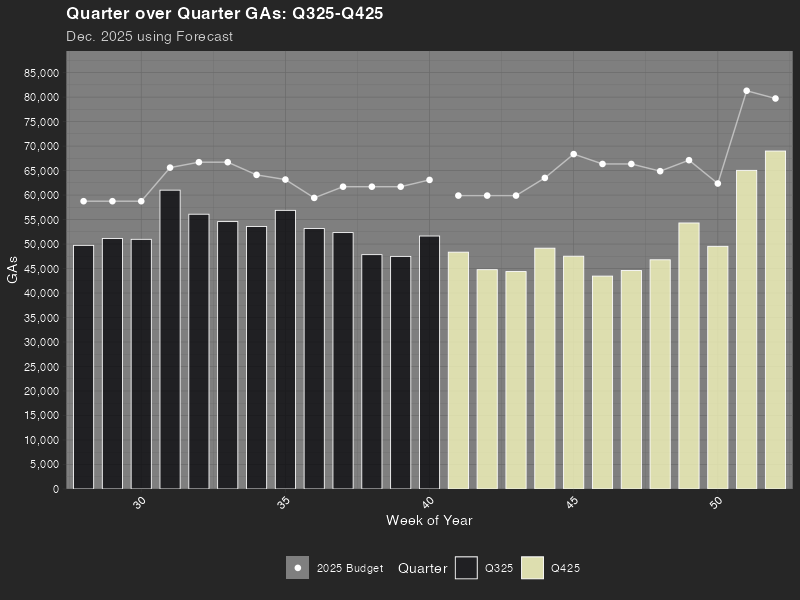

Warning messages:
1: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.


In [255]:
qoq_25 <- subset(weekly_labeled, Quarter %in% c('2025 Q3','2025 Q4') & week_start != "2025-12-29")

# TRICK: Create a common x-axis index (Week Number)
# Depending on your data structure, you might use isoweek() or just rank the weeks.
qoq_25$Week_Index <- isoweek(qoq_25$week_start)

qoq_25 <- qoq_25 %>% 
  mutate(BUDGETS = na_if(BUDGETS, 0))

qoq_25 <- qoq_25 %>%
  mutate(FC_Impute_Flag = (ifelse(ACTUALS == 0, 1, 0))) %>%
  mutate(ACTUALS = (ifelse(ACTUALS == 0, FORECASTS, ACTUALS)))

ggplot(qoq_25, aes(x = Week_Index, group = Quarter_Factor)) + 
  
    # TRENDLINE: Darker shade (solid color)
#  geom_line(stat="smooth", method = "loess", aes(y = ACTUALS, color = Quarter_Factor), 
#              se = FALSE, 
#              span = 1,
#              linewidth = 1, linetype = "longdash") +
  
  # BARS: Side-by-side with dodge
  geom_col(aes(y = ACTUALS, fill = Quarter_Factor), color = "white", linewidth = 0.3, 
           position = position_dodge(width = 0.8), 
           width = 0.7,
          alpha=0.75) + 
  
  # POINTS (Budget)
  geom_point(aes(y = BUDGETS, shape = "2025 Budget"), 
             color = "white", 
             size = 2) +
   geom_line(linewidth=0.5, alpha=0.5, aes(y = BUDGETS), color = "white")+
  
  # SCALES
  scale_fill_viridis_d(option="A", name = "Quarter", labels = c("Q325", "Q425"))+
  scale_color_viridis_d(option="A", name = "Trend", labels = c("Q325", "Q425")) +
  scale_shape_manual(name = "", values = c("2025 Budget" = 16)) +
  
  # AXIS FORMATTING
  scale_y_continuous(labels = scales::comma, 
                     n.breaks = 15, 
                     name = "GAs",
                    expand = expansion(mult = c(0, 0.1))) +
  
  scale_x_continuous(breaks = pretty_breaks(), name = "Week of Year", expand = expansion(mult = c(0.01, 0.01))) +
  labs(title="Quarter over Quarter GAs: Q325-Q425", subtitle = "Dec. 2025 using Forecast")+
  theme_dark()+
  theme(
    # 1. Background Colors (The "Frame" Effect)
    panel.background = element_rect(fill = "grey50", color = NA), # The inner plot area (Standard theme_dark)
    plot.background  = element_rect(fill = "#262626", color = NA), # The outer frame (Darker!)
    legend.background = element_rect(fill = "#262626", color = NA), # Matches the frame
    legend.key = element_rect(fill = "grey50", color = NA),         # Matches the panel

    # 2. Text Colors (Everything White)
    text = element_text(color = "white"),                   # Global text default
    axis.text = element_text(color = "white"),              # Axes ticks
    axis.title = element_text(color = "white"),             # Axes labels
    plot.title = element_text(color = "white", face="bold"),# Title
    plot.subtitle = element_text(color = "#cccccc"),        # Subtitle (Slightly dimmer white)
    legend.text = element_text(color = "white"),            # Legend items
    legend.title = element_text(color = "white"),           # Legend title
    
    # 3. Positioning
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.margin = margin(t = 10, b = 10),
    
    # 4. Remove outer border if desired
    panel.border = element_blank(),
    main_family = "roboto"
  )
ggsave("QoQ25.png", path = "./plts/", width = 12, height = 7.5, dpi = 300)

In [256]:
bfcm_weeks <- subset(combined_GA, Date %in% as.Date(c('2024-11-24', '2024-12-01', 
                                             '2025-11-23', '2025-11-30')))

Warning messages:
1: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
2: Removed 14 rows containing missing values or values outside the scale range (`geom_point()`). 
3: Removed 14 rows containing missing values or values outside the scale range (`geom_line()`). 


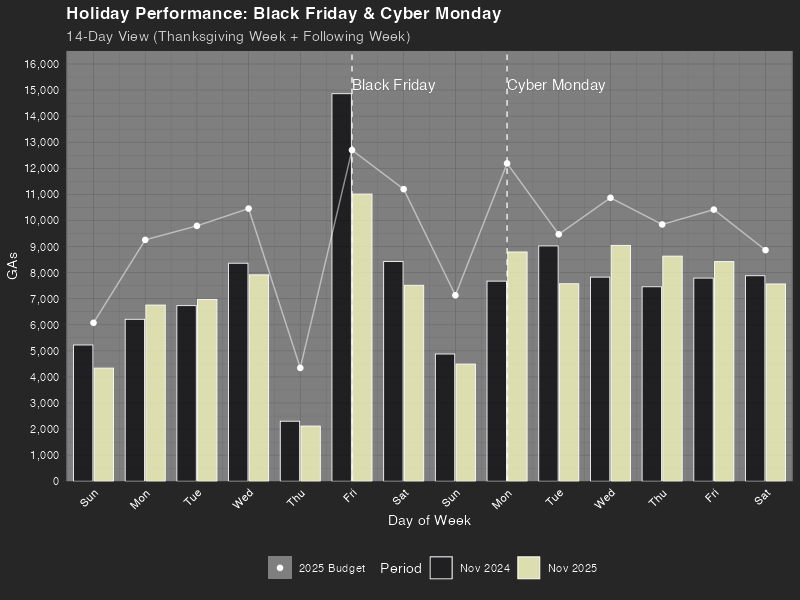

Warning messages:
1: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `main_family` theme element is not defined in the element hierarchy.
3: Removed 14 rows containing missing values or values outside the scale range (`geom_point()`). 
4: Removed 14 rows containing missing values or values outside the scale range (`geom_line()`). 


In [257]:
library(ggplot2)
library(dplyr)
library(scales)

# 1. DATA PREP
bfcm_days <- combined_GA %>%
  filter(
    between(Date, as.Date('2024-11-24'), as.Date('2024-12-07')) |
    between(Date, as.Date('2025-11-23'), as.Date('2025-12-06'))
  ) %>%
  group_by(Quarter_Factor) %>%
  mutate(
    Day_Index = rank(Date) 
  ) %>%
  ungroup()

# 2. CREATE LABELS
# Since we know Day 1 is Sunday, we map the 14 days manually:
day_labels <- c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", 
                "Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat")

# 3. PLOT
ggplot(bfcm_days, aes(x = Day_Index, group = Quarter_Factor)) + 
  
  # --- ANNOTATIONS (FLAGS) ---
  # We add these first so they sit behind the data lines but are clearly visible
  # Black Friday is Day 6
  geom_vline(xintercept = 6, linetype = "dashed", color = "white", alpha = 0.9) +
  annotate("text", x = 6, y = 15000, label = "Black Friday", angle = 0, vjust = 0, hjust = 0, color = "white", size = 4) +
  
  # Cyber Monday is Day 9
  geom_vline(xintercept = 9, linetype = "dashed", color = "white", alpha = 0.9) +
  annotate("text", x = 9, y = 15000, label = "Cyber Monday", angle = 0, vjust = 0, hjust = 0, color = "white", size = 4) +
  # ---------------------------

  # TRENDLINE
#  geom_smooth(aes(y = ACTUALS, color = Quarter_Factor), 
#              se = FALSE, 
#              span = 0.75, # Reduced span slightly to make the daily peaks of BF/CM sharper
#              linewidth = 0.5,
#            linetype = "longdash") + 

  geom_col(aes(y = ACTUALS, fill = Quarter_Factor),color = "white", linewidth = 0.3,
           position = position_dodge(width = 0.8), 
           width = 0.75, 
           alpha = 0.75) + 

  
  # BUDGET POINTS
  geom_point(aes(y = BUDGETS, shape = "2025 Budget"), 
             color = "white", 
             size = 2) +
   geom_line(linewidth=0.5, alpha=0.5, aes(y = BUDGETS), color = "white")+
  
  # SCALES
  scale_fill_viridis_d(name = "Period", labels = c("Nov 2024", "Nov 2025"), option = "A") +
  scale_color_viridis_d(name = "Trend", labels = c("Nov 2024", "Nov 2025"), option = "A") +
  scale_shape_manual(name = "", values = c("2025 Budget" = 16)) +
  
  # Y-AXIS
  scale_y_continuous(labels = scales::comma, n.breaks = 15, name = "GAs", expand = expansion(mult = c(0, 0.1))) +
  
  # X-AXIS (THE DAY LABELS)
  scale_x_continuous(
    breaks = 1:14,       # Where the ticks go (every day)
    labels = day_labels, # What text to show
    name = "Day of Week",
    expand = expansion(mult = c(0.01, 0.01))
  ) +
  
  labs(title = "Holiday Performance: Black Friday & Cyber Monday", 
       subtitle = "14-Day View (Thanksgiving Week + Following Week)") +

  theme_dark() +
  
  # Rotate x-axis labels slightly if they overlap
    theme(
    # 1. Background Colors (The "Frame" Effect)
    panel.background = element_rect(fill = "grey50", color = NA), # The inner plot area (Standard theme_dark)
    plot.background  = element_rect(fill = "#262626", color = NA), # The outer frame (Darker!)
    legend.background = element_rect(fill = "#262626", color = NA), # Matches the frame
    legend.key = element_rect(fill = "grey50", color = NA),         # Matches the panel

    # 2. Text Colors (Everything White)
    text = element_text(color = "white"),                   # Global text default
    axis.text = element_text(color = "white"),              # Axes ticks
    axis.title = element_text(color = "white"),             # Axes labels
    plot.title = element_text(color = "white", face="bold"),# Title
    plot.subtitle = element_text(color = "#cccccc"),        # Subtitle (Slightly dimmer white)
    legend.text = element_text(color = "white"),            # Legend items
    legend.title = element_text(color = "white"),           # Legend title
    
    # 3. Positioning
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.margin = margin(t = 10, b = 10),
    
    # 4. Remove outer border if desired
    panel.border = element_blank(),
    main_family = "roboto"
  )

ggsave("BFCM.png", path = "./plts/", width = 12, height = 7.5, dpi = 300)

In [258]:
bfcm_spend <- spending %>%
  filter(
    between(Date, as.Date('2024-11-24'), as.Date('2024-12-07')) |
    between(Date, as.Date('2025-11-23'), as.Date('2025-12-06'))
  ) %>%
  mutate(
    Quarter_Factor = if_else(Date < as.Date('2025-01-01'), "Nov 2024", "Nov 2025"))


Warning message:
In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


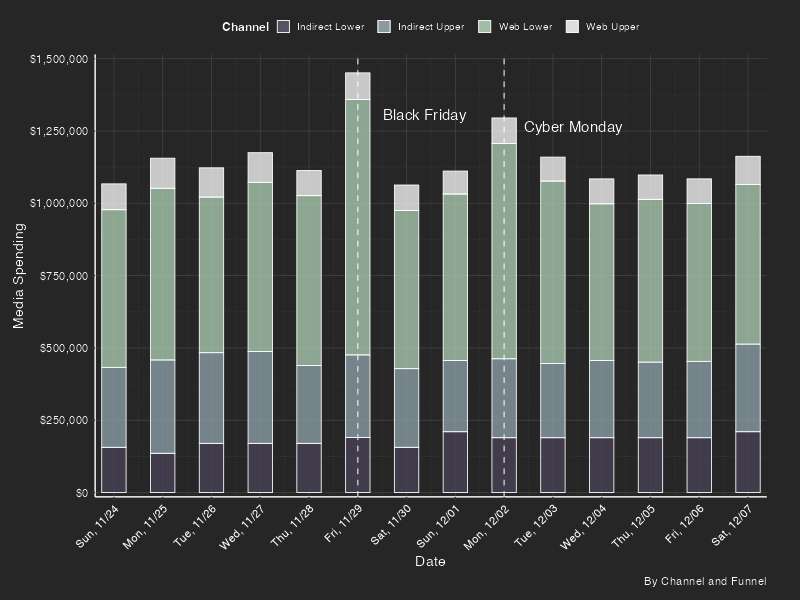

Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


In [259]:
#2024 Spending

source("dark_vibes.r")
cols <- paletteer::paletteer_d("futurevisions::kepler186", n = 8)

a <- bfcm_spend %>% filter(year(Date) < 2025) %>%
  mutate(combined_fill = interaction(Sales_Channel, 
    Funnel, sep = " "), 
    combined_fill = fct_relevel(combined_fill,
      "Indirect Lower", 
      "Indirect Upper" ,
      "Web Lower",      
      "Web Upper",
    )
  ) %>%
  ggplot(aes(x = Date, y = Spend, fill = combined_fill
    )
  ) +
  geom_col(alpha= 0.75, 
    color = "white", 
    linewidth = 0.3, 
    width = 0.5,
    position = position_stack(reverse = TRUE))+
  scale_fill_manual(
    name = "Channel",
    values = cols[c(8, 7, 6, 5)] 
  ) +
  scale_y_continuous(n.breaks = 7 ,
    expand = c(0.01, 0.01), 
    limits = c(0, 1500000), 
    labels=scales::dollar_format()) +
  scale_x_date(date_breaks = "1 day", 
    date_labels = "%a, %m/%d", 
    expand = expansion(mult = 0.01)) +
  labs(caption = "By Channel and Funnel", y = "Media Spending") +
  dark_vibes() +   
  theme(axis.text.x = element_text(angle = 45, 
    hjust = 1),
    axis.line.x = element_line(color = 'white', 
    linetype = 'solid'),
    axis.line.y = element_line(color = 'white', 
    linetype = 'solid')) +
  geom_vline(xintercept = as.Date("2024-11-29"), 
    color = "white", 
    linetype = "dashed", 
    alpha = 0.7) + 
  annotate("text", 
    x = as.Date("2024-11-29"), 
    y = 1250000, label = "Black Friday", 
    angle = 0, 
    vjust = -1, 
    hjust = -0.3, 
    color = "white", 
    size = 4) +
  geom_vline(xintercept = as.Date("2024-12-02"), 
    color = "white", 
    linetype = "dashed", 
    alpha = 0.7) + 
  annotate("text", 
    x = as.Date("2024-12-02"), 
    y = 1250000, 
    label = "Cyber Monday", 
    angle = 0, 
    vjust = 0.1, 
    hjust = -0.2, 
    color = "white", 
    size = 4)
  
  
a
ggsave("bfcm_spend_24.png", path = "./plts/", width = 12, height = 7.5, dpi = 300)

Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: Removed 4 rows containing missing values or values outside the scale range (`geom_col()`). 


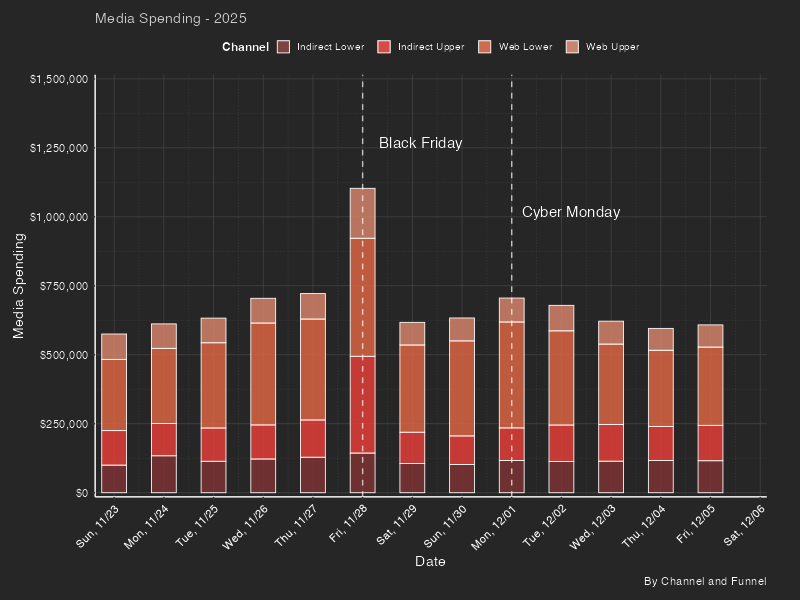

Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
3: Removed 4 rows containing missing values or values outside the scale range (`geom_col()`). 


In [260]:
#2025 Spending

source("dark_vibes.r")
cols <- paletteer::paletteer_d("futurevisions::kepler186", n = 5)

b <- bfcm_spend %>% 
  filter(year(Date) > 2024) %>% 
  mutate(combined_fill = interaction(Sales_Channel, 
    Funnel, sep = " "), 
    combined_fill = fct_relevel(combined_fill,
      "Indirect Lower", 
      "Indirect Upper" ,
      "Web Lower",      
      "Web Upper",      
    )
  ) %>%
ggplot(aes(x = Date, y = Spend, fill = combined_fill)) +
  geom_col(alpha = 0.8,
    color = "white",
    linewidth = 0.3,
    width = 0.5,
    position = position_stack(reverse = TRUE)
  ) +
  scale_fill_manual(
    name = "Channel",
    values = cols[c(1, 2, 3, 4)] 
  ) +
  scale_y_continuous(n.breaks = 7, 
    expand = c(0.01, 0.01), 
    limits = c(0, 1500000), 
    labels=scales::dollar_format())+
  scale_x_date(date_breaks = "1 day",
              date_labels = "%a, %m/%d",
              expand = expansion(mult = 0.01),
              limits = c(as.Date(NA), as.Date("2025-12-06")))+
  labs(subtitle = "Media Spending - 2025",
    caption = "By Channel and Funnel", y = "Media Spending") +
  dark_vibes() +
  theme(axis.text.x = element_text(angle = 45, 
      hjust = 1
    ),
      axis.line.x = element_line(color = 'white', 
        linetype = 'solid'
      ),
    axis.line.y = element_line(color = 'white', 
    linetype = 'solid')) +
  geom_vline(xintercept = as.Date("2025-11-28"),
    color = "white",
    linetype = "dashed", alpha = 0.7) + 
  annotate("text", 
    x = as.Date("2025-11-28"), 
    y = 1250000, 
    label = "Black Friday", 
    angle = 0, 
    vjust = 0, 
    hjust = -0.2, 
    color = "white", 
    size = 4) +
  geom_vline(xintercept = as.Date("2025-12-01"), 
    color = "white", 
    linetype = "dashed", 
    alpha = 0.7) + 
  annotate("text", 
    x = as.Date("2025-12-01"), 
    y = 1000000, 
    label = "Cyber Monday", 
    angle = 0, 
    vjust = 0, 
    hjust = -0.1, 
    color = "white", 
    size = 4)
  
b
ggsave("bfcm_spend_25.png", path = "./plts/", width = 12, height = 7.5, dpi = 300)

Warning message:
In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


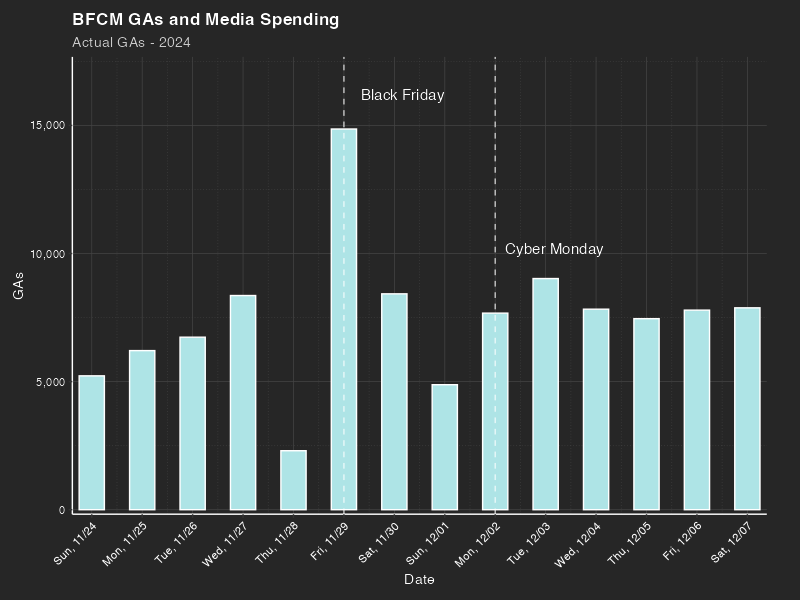

In [261]:
# 2024 GAs

c <- bfcm_days %>% 
  filter(year(Date) < 2025) %>%
ggplot(aes(x = Date, y = ACTUALS)) + 
geom_col(fill = "#aee4e6ff", 
  color = "white", 
  linewidth = 0.5, 
  width = 0.5) + 
dark_vibes() +
scale_x_date(date_breaks = "1 day", 
  date_labels = "%a, %m/%d", 
  expand = expansion(mult = 0.01)) +
theme(axis.text.x = element_text(angle = 45, 
  hjust = 1),
  axis.line.x = element_line(color = 'white', 
  linetype = 'solid'),
  axis.line.y = element_line(color = 'white', 
  linetype = 'solid')) +
labs(title="BFCM GAs and Media Spending", 
    subtitle = "Actual GAs - 2024") +
scale_y_continuous(labels=scales::comma_format(), 
    name = "GAs",
    limits = c(0,17500),
    n.breaks = 6,
    expand = c(0.01, 0.01)) +
  geom_vline(xintercept = as.Date("2024-11-29"), 
    color = "white", 
    linetype = "dashed", 
    alpha = 0.7) + 
  annotate("text", 
    x = as.Date("2024-11-29"), 
    y = 16000, 
    label = "Black Friday", 
    angle = 0, 
    vjust = 0, 
    hjust = -0.2, 
    color = "white", 
    size = 4) +
  geom_vline(xintercept = as.Date("2024-12-02"), 
    color = "white", 
    linetype = "dashed", 
    alpha = 0.7) + 
  annotate("text", 
    x = as.Date("2024-12-02"), 
    y = 10000, 
    label = "Cyber Monday", 
    angle = 0, 
    vjust = 0, hjust = -0.1, 
    color = "white", 
    size = 4)
  

c

Warning message:
In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


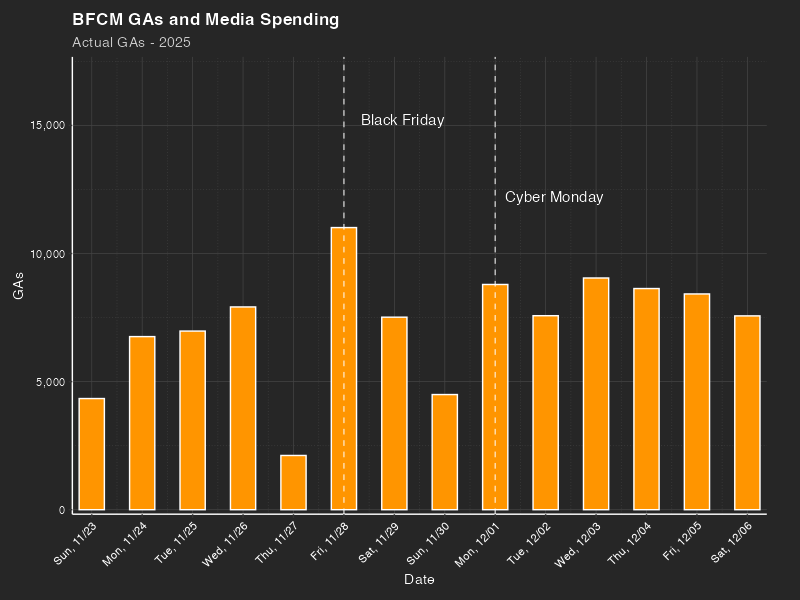

In [262]:
# 2025 GAs

d <- bfcm_days %>% filter(year(Date) > 2024) %>%
ggplot(aes(x = Date, y = ACTUALS)) +
  #geom_line(aes(y = BUDGETS), color = 'white', fill = 'white', linetype = 'dotted') +
  geom_col(fill = "#ff9500", 
    color = "white", 
    linewidth = 0.5, 
    width = 0.5) +
  scale_x_date(date_breaks = "1 day", 
    date_labels = "%a, %m/%d", 
    expand = expansion(mult = 0.01))+
  dark_vibes() + 
  theme(axis.text.x = element_text(angle = 45, 
    hjust = 1),
    axis.line.x = element_line(color = 'white', 
      linetype = 'solid'),
    axis.line.y = element_line(color = 'white', 
      linetype = 'solid')) +
  labs(title="BFCM GAs and Media Spending", 
    subtitle = "Actual GAs - 2025") +
  scale_y_continuous(labels=scales::comma_format(), name = "GAs", 
    limits = c(0,17500),
    n.breaks = 6,
    expand = c(0.01, 0.01)) + 
  geom_vline(xintercept = as.Date("2025-11-28"), color = "white", 
    linetype = "dashed", 
    alpha = 0.7) + 
  annotate("text", 
    x = as.Date("2025-11-28"), 
    y = 15000, 
    label = "Black Friday", 
    angle = 0, 
    vjust = 0, 
    hjust = -0.2, 
    color = "white", 
    size = 4) +
  geom_vline(xintercept = as.Date("2025-12-01"), 
    color = "white", 
    linetype = "dashed", alpha = 0.7) + 
  annotate("text", 
    x = as.Date("2025-12-01"), 
    y = 12000, label = "Cyber Monday", 
    angle = 0, 
    vjust = 0, 
    hjust = -0.1, 
    color = "white", 
    size = 4)


d

Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


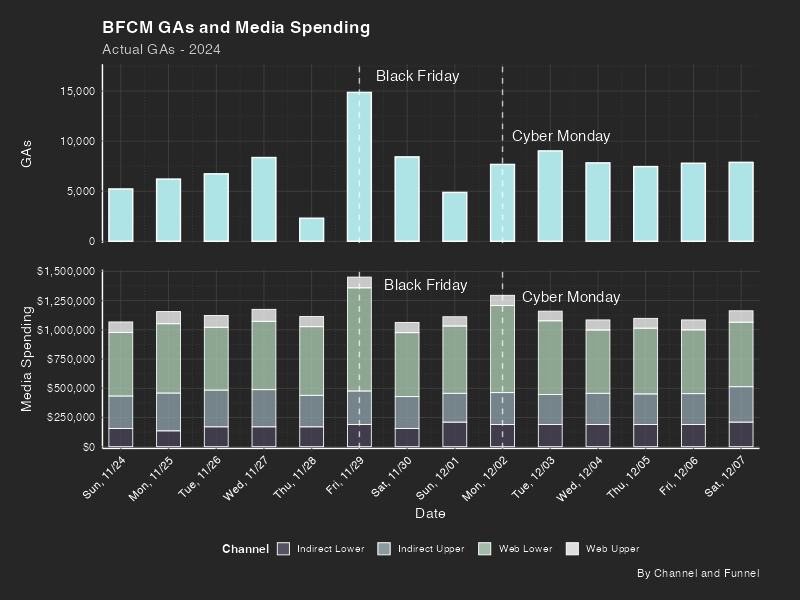

In [263]:
bfcm_2024 <- c / a + 
  plot_layout(heights = c(1, 1), guides = "collect", axes = "collect") & 
  theme(legend.position = "bottom",
        legend.box = "horizontal",
        legend.spacing.x = unit(0.2, "cm"),
        axis.line.x = element_line(color = 'white', linetype = 'solid'),
        axis.line.y = element_line(color = 'white', linetype = 'solid'),
        plot.background = element_rect(fill = "#262626", color = NA),
        #plot.margin = margin(0, 0, 0, 0)
      )

bfcm_2024

In [264]:
ggsave("bfcm_2024.png", width = 12, height = 7.5, dpi = 300, path = "./plts/", bg = "#262626")

Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
3: Removed 4 rows containing missing values or values outside the scale range (`geom_col()`). 


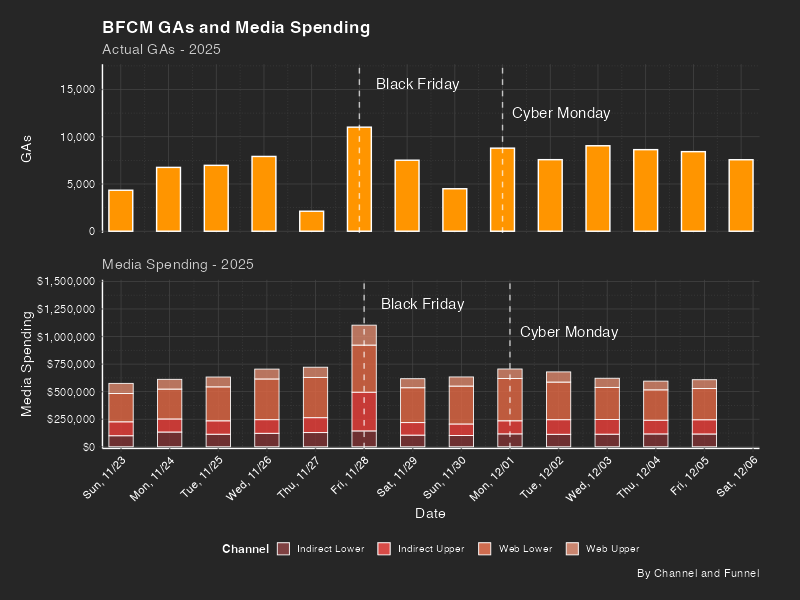

In [265]:
bfcm_2025 <- d / b + 
  plot_layout(heights = c(1, 1), guides = "collect", axes = "collect") & 
  theme(legend.position = "bottom",
        legend.box = "horizontal",
        legend.spacing.x = unit(0.2, "cm"),
        axis.line.x = element_line(color = 'white', linetype = 'solid'),
        axis.line.y = element_line(color = 'white', linetype = 'solid'),
        plot.background = element_rect(fill = "#262626", color = NA),
        #plot.margin = margin(0, 0, 0, 0)
      )

bfcm_2025

In [266]:
ggsave("bfcm_2025.png", width = 12, height = 7.5, dpi = 300, path = "./plts/", bg = "#262626")


Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
3: Removed 4 rows containing missing values or values outside the scale range (`geom_col()`). 


Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
3: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


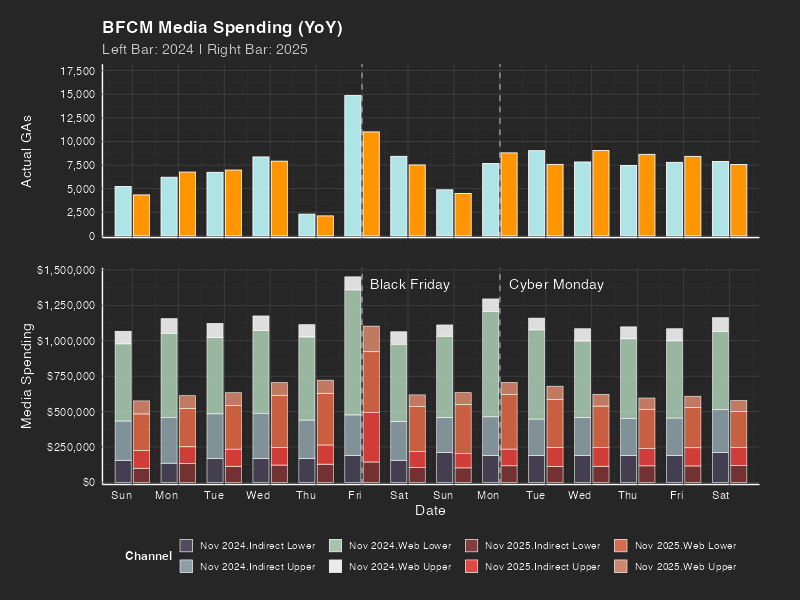

In [267]:
library(tidyverse)
library(patchwork)
library(lubridate)
library(scales)

# --- 1. Data Prep ---

# Define the Date Ranges
range_24_start <- as.Date('2024-11-24')
range_24_end   <- as.Date('2024-12-07')
range_25_start <- as.Date('2025-11-23')
range_25_end   <- as.Date('2025-12-06')

# Prepare Spending Data with Day_Index and Shift
bfcm_spend_combined <- spending %>%
  filter(
    between(Date, range_24_start, range_24_end) |
    between(Date, range_25_start, range_25_end)
  ) %>%
  mutate(
    Quarter_Factor = if_else(Date < as.Date('2025-01-01'), "Nov 2024", "Nov 2025"),
    # Create a Day Index (1 to 14) to align the years
    Day_Index = if_else(Quarter_Factor == "Nov 2024", 
                        as.numeric(Date - range_24_start) + 1,
                        as.numeric(Date - range_25_start) + 1),
    # Create the Combined Factor for Stacking
    stack_group = interaction(Sales_Channel, Funnel, sep = " "),
    stack_group = fct_relevel(stack_group,
      "Indirect Lower", "Indirect Upper", "Web Lower", "Web Upper"
    ),
    # Create a unique ID for Coloring (Year + Channel) to keep your specific palette
    fill_id = interaction(Quarter_Factor, stack_group) 
  ) %>%
  # Shift Logic: Move 2024 left (-0.2) and 2025 right (+0.2)
  mutate(x_pos = if_else(Quarter_Factor == "Nov 2024", Day_Index - 0.2, Day_Index + 0.2))

# Prepare GA Data with Day_Index
bfcm_ga_combined <- combined_GA %>%
  filter(
    between(Date, range_24_start, range_24_end) |
    between(Date, range_25_start, range_25_end)
  ) %>%
  mutate(
    Quarter_Factor = if_else(Date < as.Date('2025-01-01'), "Nov 2024", "Nov 2025"),
    Day_Index = if_else(Quarter_Factor == "Nov 2024", 
                        as.numeric(Date - range_24_start) + 1,
                        as.numeric(Date - range_25_start) + 1)
  )

# --- 2. Setup Visuals ---

source("dark_vibes.r")
base_cols <- paletteer::paletteer_d("futurevisions::kepler186", n = 8)

# Map your specific colors to the specific Year-Channel combos
# 2024 uses indices 8,7,6,5 | 2025 uses indices 1,2,3,4
color_mapping <- c(
  "Nov 2024.Indirect Lower" = base_cols[8],
  "Nov 2024.Indirect Upper" = base_cols[7],
  "Nov 2024.Web Lower"      = base_cols[6],
  "Nov 2024.Web Upper"      = base_cols[5],
  "Nov 2025.Indirect Lower" = base_cols[1],
  "Nov 2025.Indirect Upper" = base_cols[2],
  "Nov 2025.Web Lower"      = base_cols[3],
  "Nov 2025.Web Upper"      = base_cols[4]
)

# Custom X-axis labels (Day of week matches for both years)
day_labels <- c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", 
                "Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat")

# Indices for BF and CM
bf_idx <- 6 # Friday
cm_idx <- 9 # Monday

# --- 3. Plotting ---

# PLOT 1: SPENDING (Side-by-Side Stacks)
p_spend <- ggplot(bfcm_spend_combined, aes(x = x_pos, y = Spend, fill = fill_id)) +
  geom_col(
    width = 0.35, # Make bars thinner so they fit side-by-side
    color = "white", 
    linewidth = 0.2, 
    position = position_stack(reverse = TRUE),
    alpha = 0.85
  ) +
  scale_fill_manual(values = color_mapping,
     name = "Channel",
     ) + # Hide legend if implied, or adjust
  scale_y_continuous(
    labels = scales::dollar_format(), 
    limits = c(0, 1500000), 
    expand = c(0.01, 0.01),
    n.breaks = 7
  ) +
  scale_x_continuous(
    breaks = 1:14, 
    labels = day_labels,
    expand = expansion(mult = 0.02)
  ) +
  labs(
    y = "Media Spending",
    x = "Date"
  ) +
  dark_vibes() +
  theme(
    axis.line.x = element_blank()
  ) +
  # Annotations
  geom_vline(xintercept = bf_idx, color = "white", linetype = "dashed", alpha = 0.5) +
  annotate("text", x = bf_idx, y = 1400000, label = "Black Friday", color = "white", hjust = -0.1) +
  geom_vline(xintercept = cm_idx, color = "white", linetype = "dashed", alpha = 0.5) +
  annotate("text", x = cm_idx, y = 1400000, label = "Cyber Monday", color = "white", hjust = -0.1)


# PLOT 2: GAs (Side-by-Side Bars)
p_ga <- ggplot(bfcm_ga_combined, aes(x = Day_Index, y = ACTUALS, fill = Quarter_Factor)) +
  geom_col(
    position = position_dodge(width = 0.8), 
    width = 0.7, 
    color = "white", 
    linewidth = 0.3
  ) +
  scale_fill_manual(
    values = c("Nov 2024" = "#aee4e6ff", "Nov 2025" = "#ff9500"),
    name = "Year", 
    guide = "none"
  ) +
  scale_x_continuous(
    breaks = 1:14, 
    labels = day_labels,
    expand = expansion(mult = 0.02)
  ) +
  scale_y_continuous(
    labels = scales::comma_format(), 
    limits = c(0, 18000),
    expand = c(0.01, 0.01),
    n.breaks = 8
  ) +
  labs(
    title = "BFCM Media Spending (YoY)",
    subtitle = "Left Bar: 2024 | Right Bar: 2025",
    y = "Actual GAs", 
    x = NULL
  ) +
  dark_vibes() +
  theme(
    legend.position = "bottom",
    axis.text.x = element_blank()
  ) +
  # Annotations
  geom_vline(xintercept = bf_idx, color = "white", linetype = "dashed", alpha = 0.5) +
  geom_vline(xintercept = cm_idx, color = "white", linetype = "dashed", alpha = 0.5)


# --- 4. Patchwork ---

final_plot <-  p_ga / p_spend + 
  plot_layout(heights = c(1, 1.25), guides = "collect", axes = "collect") & # Give Spending a bit more height
  theme(legend.position = "bottom",
        legend.box = "horizontal",
        legend.spacing.x = unit(0.2, "cm"),
        axis.line.x = element_line(color = 'white', linetype = 'solid'),
        axis.line.y = element_line(color = 'white', linetype = 'solid'),
        plot.background = element_rect(fill = "#262626", color = NA),
        #plot.margin = margin(0, 0, 0, 0)
      )

# Save
ggsave("bfcm_combined_yoy.png", final_plot, path = "./plts/", width = 16, height = 9, dpi = 300)

final_plot

In [268]:
# Search Stuff 
rm(list = ls())

data_list <- list.files(path = "/Users/Ben.Pharris/Downloads/boostmobile.com-Performance-on-Search-2025-12-10", pattern = "\\.csv$", full.names = TRUE) %>%
  set_names(basename(.) %>% tools::file_path_sans_ext()) %>%
  map(read_csv)



Rows: 14 Columns: 5
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): CTR
dbl  (3): Clicks, Impressions, Position
date (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 238 Columns: 5
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Country, CTR
dbl (3): Clicks, Impressions, Position

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3 Columns: 5
── Column specification ────────────────────────────────────────────

In [269]:
for (name in names(data_list)) {
  
  df <- data_list[[name]]
  
  assign(paste0("df_", name), df, envir = .GlobalEnv)
}

In [270]:
df_Chart$CTR <- parse_number(df_Chart$CTR) / 100

Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
3: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


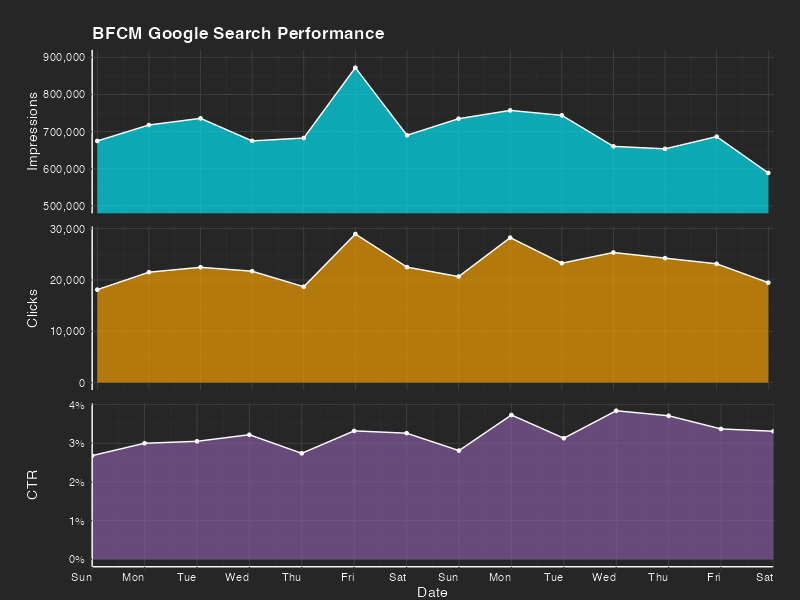

Warning messages:
1: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
2: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
3: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.
4: In plot_theme(plot) :
  The `legend.title.spacing` theme element is not defined in the element hierarchy.


In [271]:
library(ggbreak)
source("dark_vibes.r")


a <- ggplot(df_Chart, aes(x = Date, y = Impressions))+
  geom_area(fill = "#00eeffff", color = "white", alpha = 0.65) +
    geom_point(color = "white", size = 1)+
  dark_vibes() +
  scale_x_date(date_breaks = "day", date_labels = "%a", expand = c(0, 0.1)) +
  scale_y_continuous(labels = scales::comma_format(), n.breaks = 4) +
  coord_cartesian(ylim = c(500000, 900000)) +
  labs(title = "BFCM Google Search Performance") +
  theme(axis.line.x = element_line(color = 'white', linetype = 'solid'),
        axis.line.y = element_line(color = 'white', linetype = 'solid'))

b <- ggplot(df_Chart, aes(x = Date, y = Clicks)) +
  geom_area(fill = "#ffa600ff", color="white", alpha = 0.65) +
    geom_point(color = "white", size = 1)+
  dark_vibes() +
  scale_x_date(date_breaks = "day", date_labels = "%a", expand = c(0, 0.1)) +
  scale_y_continuous(labels = scales::comma_format()) + 
  theme( axis.line.x = element_line(color = 'white', linetype = 'solid'),
        axis.line.y = element_line(color = 'white', linetype = 'solid'),)



c <- ggplot(df_Chart, aes(x = Date, y = CTR)) +
  geom_area(fill = "#8c5ea7ff", color="white", alpha = 0.65) +
  geom_point(color = "white", size = 1)+
  dark_vibes() +
  scale_x_date(date_breaks = "day", date_labels = "%a", expand = c(0, 0)) +
  scale_y_continuous(labels = scales::percent_format()) + 
  theme( axis.line.x = element_line(color = 'white', linetype = 'solid'),
        axis.line.y = element_line(color = 'white', linetype = 'solid'),)

final_plot <-  a / b / c + 
  plot_layout(heights = c(1, 1, 1), guides = "collect", axes = "collect") &
  theme(
        plot.background = element_rect(fill = "#262626", color = NA),
        plot.margin = margin(t = 10, r = 10, b = 0, l = 10, unit = "pt")
  )

final_plot

ggsave("bfcm_search_performance.png", final_plot, path = "./plts/", width = 16, height = 9, dpi = 300)

In [272]:
str(df_Queries)

spc_tbl_ [1,000 × 5] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Top queries: chr [1:1000] "boost mobile" "boost mobile pay bill" "boost mobile login" "boost" ...
 $ Clicks     : num [1:1000] 100298 11343 6297 5898 3717 ...
 $ Impressions: num [1:1000] 786639 16048 9261 106335 88303 ...
 $ CTR        : chr [1:1000] "12.75%" "70.68%" "67.99%" "5.55%" ...
 $ Position   : num [1:1000] 1.33 1.12 1.36 3.18 1.6 2.25 1.34 1.2 1.76 2.73 ...
 - attr(*, "spec")=
  .. cols(
  ..   `Top queries` = col_character(),
  ..   Clicks = col_double(),
  ..   Impressions = col_double(),
  ..   CTR = col_character(),
  ..   Position = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


In [273]:
library(tidyverse)
library(gt)
library(gtExtras)

query_table <- df_Queries %>%
  arrange(desc(Clicks)) %>%
  slice(1:10) %>%
  select(`Top queries`, Clicks, Impressions, CTR, Position) %>%
  gt() %>%
  # 1. Dark Theme
  gt_theme_dark() %>%
  tab_header(
    title = md("**Top 10 Search Queries**"),
    subtitle = "Ranked by Clicks"
  ) %>%
  # 2. Format Numbers (Commas) - Crucial for the numeric view
  fmt_number(columns = c(Clicks, Impressions), decimals = 0) %>%
  cols_label(
    `Top queries` = "Search Query",
    Position = "Avg. Pos"
  ) %>%
  # 3. THE FIX: Use data_color instead of gt_plt_bar
  # This highlights the cell background. Darker = Lower, Brighter Cyan = Higher
  data_color(
    columns = Clicks,
    fn = scales::col_numeric(
      palette = c("#333333", "#00e3f3"), # Fades from Dark Grey to your Cyan
      domain = NULL
    )
  ) %>%
  cols_align(align = "left", columns = `Top queries`)

# Save or View
gtsave(query_table, "top_queries_table.png", path = "./plts/")
query_table

! Reconnecting to chrome process.
ℹ All active sessions will be need to be respawned.
file:////var/folders/r8/f4vjftzx1s93lfzrk2s0hk9w0000gq/T//RtmpqnSLLE/filea94065cd4db2.html screenshot completed


<R HTML widget HTML Widget>

In [274]:
library(arrow)

doors <- read_parquet('/Users/Ben.Pharris/Documents/project-dev/Ad Hoc/doors_plt_subset.parquet')

In [275]:
doors <- doors %>% filter(CLNDR_DT < "2025-12-07")

In [276]:
print(unique(doors$REGION))

[1] "Great Lakes"   "Midwest"       "Northeast"     "Pacific Coast" "South"         "Southeast"    


In [277]:
names(doors) <- c('Date', 'Region', 'GAs', 'Door_Swings')

In [278]:
str(doors)

tibble [90 × 4] (S3: tbl_df/tbl/data.frame)
 $ Date       : POSIXct[1:90], format: "2025-11-22 17:00:00" "2025-11-22 17:00:00" "2025-11-22 17:00:00" "2025-11-22 17:00:00" ...
 $ Region     : chr [1:90] "Great Lakes" "Midwest" "Northeast" "Pacific Coast" ...
 $ GAs        : int [1:90] 406 423 638 326 558 476 714 662 905 513 ...
 $ Door_Swings: num [1:90] 10766 11392 18928 15615 13020 ...


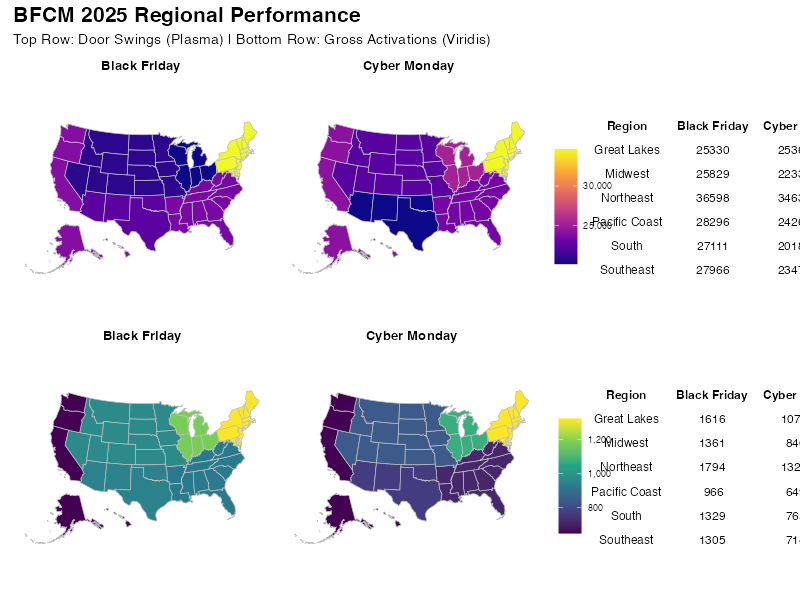

In [286]:
library(tidyverse)
library(usmap)
library(patchwork)
library(gridExtra)
library(grid)

# 1. CROSSWALK (Unchanged)
region_crosswalk <- tibble(
  state = state.abb,
  Region = case_when(
    state %in% c("WA", "OR", "CA", "AK", "HI") ~ "Pacific Coast",
    state %in% c("NY", "PA", "NJ", "CT", "MA", "RI", "VT", "NH", "ME", "DE", "MD", "DC") ~ "Northeast",
    state %in% c("FL", "GA", "NC", "SC", "VA", "WV", "AL", "MS", "TN", "KY", "LA", "AR") ~ "Southeast",
    state %in% c("TX", "OK", "NM", "AZ") ~ "South",
    state %in% c("IL", "IN", "MI", "OH", "WI") ~ "Great Lakes",
    TRUE ~ "Midwest" 
  )
)

# 2. PREP DATA (Unchanged)
clean_data <- doors %>%
  mutate(Date_Date = as.Date(Date)) %>%
  filter(Date_Date %in% as.Date(c("2025-11-28", "2025-12-01"))) %>%
  mutate(
    Day_Label = if_else(Date_Date == "2025-11-28", "Black Friday", "Cyber Monday"),
    Day_Label = factor(Day_Label, levels = c("Black Friday", "Cyber Monday"))
  ) %>%
  left_join(region_crosswalk, by = "Region", relationship = "many-to-many") %>%
  filter(!is.na(Region))

# 3. HELPER FUNCTION FOR MAPS (UPDATED!)
make_map <- function(df, metric_col, title_text, pal_option, show_legend = FALSE) {
  # --- CHANGE HERE: Added color="white" and linewidth=0.5 ---
  plot_usmap(data = df, values = metric_col, regions = "states", 
             color = "gray", linewidth = 0.25) + 
    scale_fill_viridis_c(option = pal_option, label = scales::comma) + 
    labs(title = title_text, fill = "") + 
    theme(
      plot.background = element_rect(fill = "white", color = NA),
      legend.position = if(show_legend) "right" else "none",
      plot.title = element_text(size = 10, face = "bold", hjust = 0.5)
    )
}

# 4. BUILD THE 4 MAPS (Unchanged)
bf_data <- clean_data %>% filter(Day_Label == "Black Friday")
cm_data <- clean_data %>% filter(Day_Label == "Cyber Monday")

# Row 1: Door Swings
map_swings_bf <- make_map(bf_data, "Door_Swings", "Black Friday", "plasma")
map_swings_cm <- make_map(cm_data, "Door_Swings", "Cyber Monday", "plasma", show_legend = TRUE)

# Row 2: Gross Activations (GAs)
map_gas_bf <- make_map(bf_data, "GAs", "Black Friday", "viridis")
map_gas_cm <- make_map(cm_data, "GAs", "Cyber Monday", "viridis", show_legend = TRUE)


# 5. BUILD THE TABLES (Unchanged)
table_stats <- clean_data %>%
  select(Region, Day_Label, GAs, `Door_Swings` = Door_Swings) %>%
  distinct(Region, Day_Label, .keep_all = TRUE) %>%
  pivot_wider(names_from = Day_Label, values_from = c(GAs, Door_Swings))

tt <- ttheme_minimal(base_size = 9)

# Table 1: Swings
tbl_swings_data <- table_stats %>% 
  select(Region, `Black Friday` = `Door_Swings_Black Friday`, `Cyber Mon` = `Door_Swings_Cyber Monday`)
grob_swings <- tableGrob(tbl_swings_data, rows = NULL, theme = tt)

# Table 2: GAs
tbl_gas_data <- table_stats %>% 
  select(Region, `Black Friday` = `GAs_Black Friday`, `Cyber Mon` = `GAs_Cyber Monday`)
grob_gas <- tableGrob(tbl_gas_data, rows = NULL, theme = tt)


# 6. ASSEMBLE WITH PATCHWORK (Unchanged)
row1 <- map_swings_bf + map_swings_cm + wrap_elements(grob_swings) + 
  plot_layout(widths = c(1, 1, 0.6))

row2 <- map_gas_bf + map_gas_cm + wrap_elements(grob_gas) + 
  plot_layout(widths = c(1, 1, 0.6))

final_dashboard <- row1 / row2 + 
  plot_annotation(
    title = 'BFCM 2025 Regional Performance',
    subtitle = 'Top Row: Door Swings (Plasma) | Bottom Row: Gross Activations (Viridis)',
    theme = theme(plot.title = element_text(size = 16, face = "bold"))
  )

# Display
final_dashboard

# Save
ggsave("bfcm_regional_dashboard_final.png", final_dashboard, width = 14, height = 8, bg = "white")

In [ ]:
library(ggplot2)
library(paletteer)
library(scales)

# Assuming you have sourced your theme
source("dark_vibes.r") 

door_swing_plot <- ggplot(doors, aes(x = Date, y = Door_Swings, fill = Region)) +
  # Use fill for the bar color. 
  # color = "#262626" adds a thin border matching the background to separate the stacks nicely
  geom_col(color = "white", width = 0.75) + 
  
  # Apply your base custom theme
  dark_vibes() +
  
  # Scales matched to previous plot style
  scale_x_date(date_breaks = "day", date_labels = "%a", expand = c(0, 0.1)) +
  scale_y_continuous(labels = scales::comma_format(), n.breaks = 5) +
  
  # Palette: futurevisions::kepler186 is great for dark mode (muted earthy/red/blue tones)
  scale_fill_paletteer_d("IslamicArt::konya") +
  
  labs(title = "BFCM Door Swings by Region") +
  
  # Theme overrides to match the 'final_plot' aesthetic exactly
  theme(
    # Axis lines white and solid
    axis.line.x = element_line(color = 'white', linetype = 'solid'),
    axis.line.y = element_line(color = 'white', linetype = 'solid'),
    
    # Dark Backgrounds
    plot.background = element_rect(fill = "#262626", color = NA),
    panel.background = element_rect(fill = "#262626", color = NA),
    legend.position = "none"
    
  )

# Display
door_swing_plot

# Save it using the same dimensions
ggsave("bfcm_door_swings.png", door_swing_plot, path = "./plts/", width = 16, height = 9, dpi = 300)

In [ ]:
library(ggplot2)
library(paletteer)
library(scales)

# Assuming you have sourced your theme
source("dark_vibes.r") 

ga_plot <- ggplot(doors, aes(x = Date, y = GAs, fill = Region)) +
  # Use fill for the bar color. 
  # color = "#262626" adds a thin border matching the background to separate the stacks nicely
  geom_col(color = "white", width = 0.75) + 
  
  # Apply your base custom theme
  dark_vibes() +
  
  # Scales matched to previous plot style
  scale_x_date(date_breaks = "day", date_labels = "%a", expand = c(0, 0.1)) +
  scale_y_continuous(labels = scales::comma_format(), n.breaks = 5) +
  
  # Palette: futurevisions::kepler186 is great for dark mode (muted earthy/red/blue tones)
  scale_fill_paletteer_d("IslamicArt::konya") +
  
  labs(title = "BFCM Door Swings by Region") +
  
  # Theme overrides to match the 'final_plot' aesthetic exactly
  theme(
    # Axis lines white and solid
    axis.line.x = element_line(color = 'white', linetype = 'solid'),
    axis.line.y = element_line(color = 'white', linetype = 'solid'),
    
    # Dark Backgrounds
    plot.background = element_rect(fill = "#262626", color = NA),
    panel.background = element_rect(fill = "#262626", color = NA),
    
    # Ensure Legend fits the dark theme (white text, dark bg)
    legend.background = element_rect(fill = "#262626"),
    legend.key = element_rect(fill = "#262626"),
    legend.text = element_text(color = "white"),
    legend.title = element_text(color = "white"),
    
  )

# Display
door_swing_plot

# Save it using the same dimensions
ggsave("bfcm_door_swings.png", door_swing_plot, path = "./plts/", width = 16, height = 9, dpi = 300)

In [ ]:
final_plot <- door_swing_plot / ga_plot + 
  # Use heights c(1,1) to fix the black space issue
  plot_layout(heights = c(1, 1), guides = "collect", axes = "collect") &
  theme(
    plot.background = element_rect(fill = "#262626", color = NA),
    plot.margin = margin(t = 10, r = 0, b = 0, l = 0, unit = "pt"),
    legend.position = "top",
    legend.background = element_rect(fill = "#262626"),
    legend.key = element_rect(fill = "#262626"),
    legend.text = element_text(color = "white"),
    legend.title = element_text(color = "white")
  )

final_plot

ggsave("bfcm_indirect.png", door_swing_plot, path = "./plts/", width = 16, height = 9, dpi = 300)